In [2]:
# compile results
import pickle

homedir = "/mnt/mirabelle/az6922_homedir/"
load_list = range(1,11)
seed_list = [1,2,3,4,5]
oversub_list = [0.33,1,1.67]
scheme_list = ["dringsu2","leafspine"]

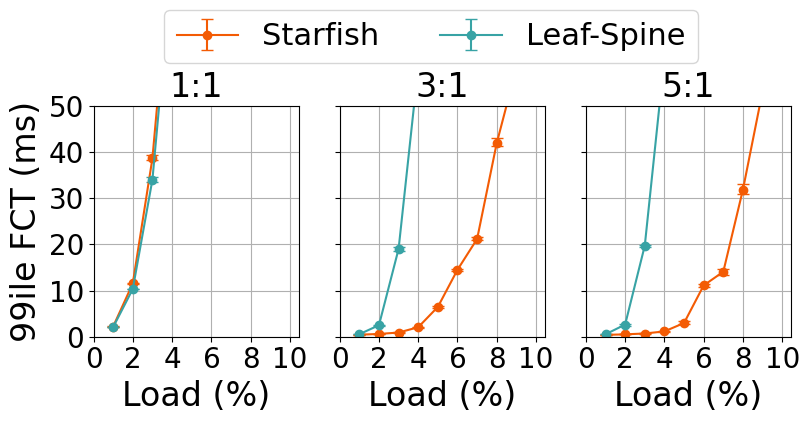

In [26]:
# plot from txt instead of pickle -- pickle files are too large
import matplotlib.pyplot as plt
import numpy as np

plottitlelist = ["1:1","3:1","5:1"]
plotlabeldict = {"dringsu2":"Starfish","dringsu2e":"Starfish (Oblivious)","leafspine":"Leaf-Spine","df2augalg":"Dragonfly","rrgsu2":"Jellyfish","dringecmp":"DRing+ECMP","dringwcmpecmp":"DRing+WCMP","dringfatpaths":"DRing+FatPaths","dringfhi":"DRing+VLB","dringracke1four":"DRing+SMORE"}
plotcolordict = {"dringsu2":"#f35b04","dringsu2e":"#f7b801","leafspine":"#38a3a5","df2augalg":"#9683ec","rrgsu2":"#5d16a6","dringecmp":"#4cc9f0","dringwcmpecmp":"#4895ef","dringfatpaths":"#4361ee","dringfhi":"#3f37c9","dringracke1four":"#3a0ca3"}

plotdatadict = dict()
sumfile = "fct_summary.txt"
with open(sumfile,'r') as f:
    # outfiles/rrgsu2_load6_seed2.out	0.05765561435997601	0.0487378	0.169153	0.746218
    lines = f.readlines()
    for line in lines:
        tokens = line.split()
        outfile = tokens[0]
        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        plotdatadict[outfile] = p99

plotevalmaindatadict = dict()
sumfile = "../eval_main/fct_summary.txt"
with open(sumfile,'r') as f:
    # outfiles/rrgsu2_load6_seed2.out	0.05765561435997601	0.0487378	0.169153	0.746218
    lines = f.readlines()
    for line in lines:
        tokens = line.split()
        outfile = tokens[0]
        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        plotevalmaindatadict[outfile] = p99


markerlist = ['o','x']
nr = 1
nc = len(oversub_list)
fig, axs =plt.subplots(nr, nc, figsize=(nc*3, nr*3),sharey='row',sharex='row')
for ic,oversub in enumerate(oversub_list):
    for isc,scheme in enumerate(scheme_list):
        
        if oversub==1:
            fct_list = list()
            for load in load_list:
                fct_list_allseeds = list()
                for seed in seed_list:
                    outfile = f"prv1/outfiles/{scheme}_load{load}_seed{seed}.out"
                    p99 = plotevalmaindatadict[outfile]
                    fct_list_allseeds.append(p99)
                fct_list.append(fct_list_allseeds)
            if ic==0:
                axs[ic].errorbar(load_list, [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], marker=markerlist[isc//10], capsize=4, color=plotcolordict[scheme], label=plotlabeldict[scheme])
            else:
                axs[ic].errorbar(load_list, [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], marker=markerlist[isc//10], capsize=4, color=plotcolordict[scheme])

        else:
            fct_list = list()
            for load in load_list:
                fct_list_allseeds = list()
                for seed in seed_list:
                    outfile = f"outfiles/{scheme}_oversub{oversub}_load{load}_seed{seed}.out"
                    p99 = plotdatadict[outfile]
                    fct_list_allseeds.append(p99)
                fct_list.append(fct_list_allseeds)
            if ic==0:
                axs[ic].errorbar(load_list, [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], marker=markerlist[isc//10], capsize=4, color=plotcolordict[scheme], label=plotlabeldict[scheme])
            else:
                axs[ic].errorbar(load_list, [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], marker=markerlist[isc//10], capsize=4, color=plotcolordict[scheme])

    axs[ic].set_xlabel("Load (%)", fontsize=24)
    if ic==0:
        axs[ic].set_ylabel("99ile FCT (ms)", fontsize=24)
    axs[ic].set_ylim(0,50)
    axs[ic].set_title(plottitlelist[ic], fontsize=24)
    axs[ic].set_xticks([0,2,4,6,8,10])
    axs[ic].set_yticks([0,10,20,30,40,50])
    axs[ic].tick_params(axis='both', labelsize=20)
    axs[ic].grid(True)
fig.legend(loc='upper center', bbox_to_anchor=(0.5,1.25),ncol=2, fontsize=22)

plt.savefig(f"eval_oversub.pdf", dpi=600, bbox_inches='tight')

starfish: 8.4/8.8
leafspine: 3.8/3.8

In [27]:
8.4/3.8

2.210526315789474

In [28]:
8.8/3.8

2.3157894736842106